In [ ]:
!pip install kagglehub opencv-python

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [ ]:
path = kagglehub.dataset_download("subhajournal/busi-breast-ultrasound-images-dataset")
data_path = os.path.join(path, "Dataset_BUSI_with_GT")

print("Dataset Path:", data_path)

100%|██████████| 195M/195M [00:01<00:00, 155MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT


In [ ]:
classes = ["benign", "malignant", "normal"]
paths, labels = [], []

for cls in classes:
    for img in os.listdir(os.path.join(data_path, cls)):
        if "_mask" not in img:
            paths.append(os.path.join(data_path, cls, img))
            labels.append(cls)

data = pd.DataFrame({"path": paths, "label": labels})

# Encode labels
data["label"] = data["label"].map({"benign":0, "malignant":1, "normal":2})

print(data.head())
print("\nClass distribution:\n", data["label"].value_counts())

                                                path  label
0  /root/.cache/kagglehub/datasets/subhajournal/b...      0
1  /root/.cache/kagglehub/datasets/subhajournal/b...      0
2  /root/.cache/kagglehub/datasets/subhajournal/b...      0
3  /root/.cache/kagglehub/datasets/subhajournal/b...      0
4  /root/.cache/kagglehub/datasets/subhajournal/b...      0

Class distribution:
 label
0    437
1    210
2    133
Name: count, dtype: int64


In [ ]:
train_df, val_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 624
Validation size: 156


In [ ]:
IMG_SIZE = 224  # Required for MobileNet

def load_image(path, label):
    img = cv2.imread(path.decode())
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img.astype(np.float32), np.int32(label)

def tf_loader(path, label):
    img, label = tf.numpy_function(load_image, [path, label], [tf.float32, tf.int32])
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    label.set_shape(())
    return img, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["path"].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["path"].values, val_df["label"].values)
)

train_ds = train_ds.map(tf_loader).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(tf_loader).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(data["label"]),
    y=data["label"]
)

class_weights = dict(enumerate(weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.5949656750572082), 1: np.float64(1.2380952380952381), 2: np.float64(1.9548872180451127)}


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.5192 - loss: 1.2344 - val_accuracy: 0.6667 - val_loss: 1.0256
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7901 - loss: 0.5030 - val_accuracy: 0.6538 - val_loss: 0.9251
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8317 - loss: 0.3572 - val_accuracy: 0.6731 - val_loss: 0.7615
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9006 - loss: 0.2565 - val_accuracy: 0.7179 - val_loss: 0.6331
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9167 - loss: 0.1899 - val_accuracy: 0.7436 - val_loss: 0.5912
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9487 - loss: 0.1670 - val_accuracy: 0.7564 - val_loss: 0.5575
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9455 - loss: 0.1466 - val_accuracy: 0.7756 - val_loss: 0.5453
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9647 - loss: 0.1039 - val_accuracy: 0.8013 - val_loss:

In [ ]:
base_model.trainable = True

# Freeze most layers, train last few
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7372 - loss: 1.0404 - val_accuracy: 0.8013 - val_loss: 0.5028
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7708 - loss: 0.6847 - val_accuracy: 0.8077 - val_loss: 0.5256
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8061 - loss: 0.5225 - val_accuracy: 0.8013 - val_loss: 0.5555
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8237 - loss: 0.4296 - val_accuracy: 0.8077 - val_loss: 0.5719
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8237 - loss: 0.4188 - val_accuracy: 0.8013 - val_loss: 0.5894


In [ ]:
loss, acc = model.evaluate(val_ds)
print("Final Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8013 - loss: 0.5894
Final Accuracy: 0.8012820482254028


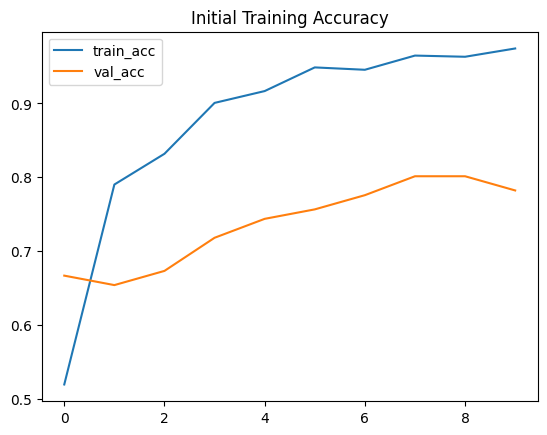

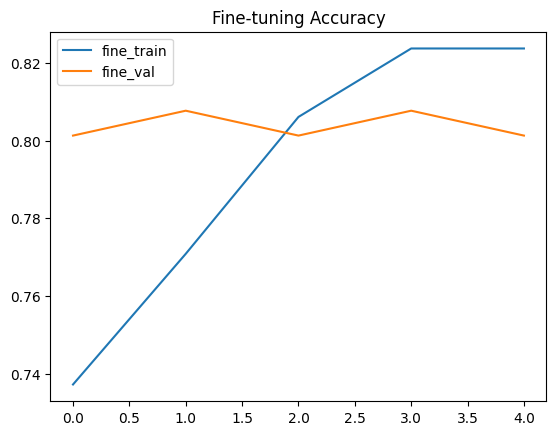

In [ ]:
# Initial training
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Initial Training Accuracy")
plt.show()

# Fine-tuning
plt.plot(history_fine.history['accuracy'], label='fine_train')
plt.plot(history_fine.history['val_accuracy'], label='fine_val')
plt.legend()
plt.title("Fine-tuning Accuracy")
plt.show()